# GTZAN Initial EDA

This notebook visualizes the local GTZAN dataset that lives at `data/genres_original`.

It covers:
- genre class distribution
- basic audio metadata checks
- one MFCC example per genre

In [19]:
from pathlib import Path
import sys

repo_root = Path.cwd()
if repo_root.name == "code":
    repo_root = repo_root.parent

code_dir = repo_root / "code"
if str(code_dir) not in sys.path:
    sys.path.insert(0, str(code_dir))

dataset_path = repo_root / "data" / "genres_original"
dataset_path

PosixPath('/Users/noahglymph/Capstone Data/audio-genre-classifier/data/genres_original')

If imports fail in your notebook kernel, install dependencies from the project root with `python -m pip install -r requirements.txt`, then restart the kernel.

In [20]:
from genre_distribution_eda import (
    build_audio_metadata,
    build_genre_counts,
    plot_genre_distribution,
    validate_gtzan_layout,
)
from mfcc_examples_eda import plot_mfcc_examples

## Genre Class Distribution

GTZAN should have 10 genre folders with 100 `.wav` files per genre.

In [21]:
genre_counts = build_genre_counts(dataset_path)
genre_counts

,genre,count
0,blues,100
1,classical,100
2,country,100
3,disco,100
4,hiphop,100
5,jazz,100
6,metal,100
7,pop,100
8,reggae,100
9,rock,100


In [22]:
validate_gtzan_layout(genre_counts)

,genre,count,status
0,blues,100,ok
1,classical,100,ok
2,country,100,ok
3,disco,100,ok
4,hiphop,100,ok
5,jazz,100,ok
6,metal,100,ok
7,pop,100,ok
8,reggae,100,ok
9,rock,100,ok


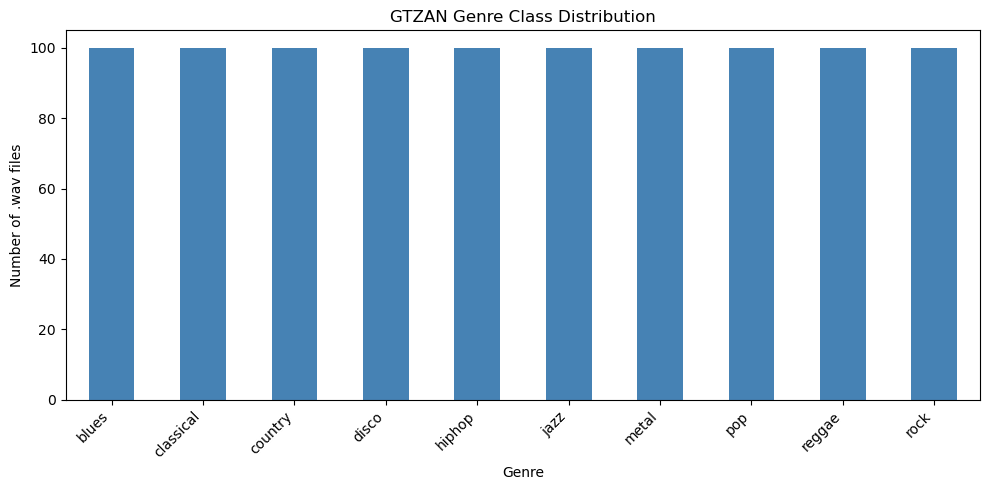

In [23]:
plot_genre_distribution(genre_counts, output_path=None)

## Audio Metadata Smoke Check

This loads a small sample with `librosa` so the notebook stays quick while still confirming audio files can be read.

In [24]:
metadata_sample = build_audio_metadata(dataset_path, limit=20)
metadata_sample.head()

,genre,file_name,sample_rate,sample_count,duration_seconds
0,blues,blues.00000.wav,22050,661794,30.013333
1,blues,blues.00001.wav,22050,661794,30.013333
2,blues,blues.00002.wav,22050,661794,30.013333
3,blues,blues.00003.wav,22050,661794,30.013333
4,blues,blues.00004.wav,22050,661794,30.013333


In [25]:
(
    metadata_sample.groupby("genre")
    .agg(
        files=("file_name", "count"),
        avg_duration_seconds=("duration_seconds", "mean"),
        min_sample_rate=("sample_rate", "min"),
        max_sample_rate=("sample_rate", "max"),
    )
    .round(2)
)

,files,avg_duration_seconds,min_sample_rate,max_sample_rate
genre,,,,
blues,20,30.01,22050,22050


## MFCC Examples By Genre

This renders one deterministic example file per genre using the first `.wav` file in each folder.

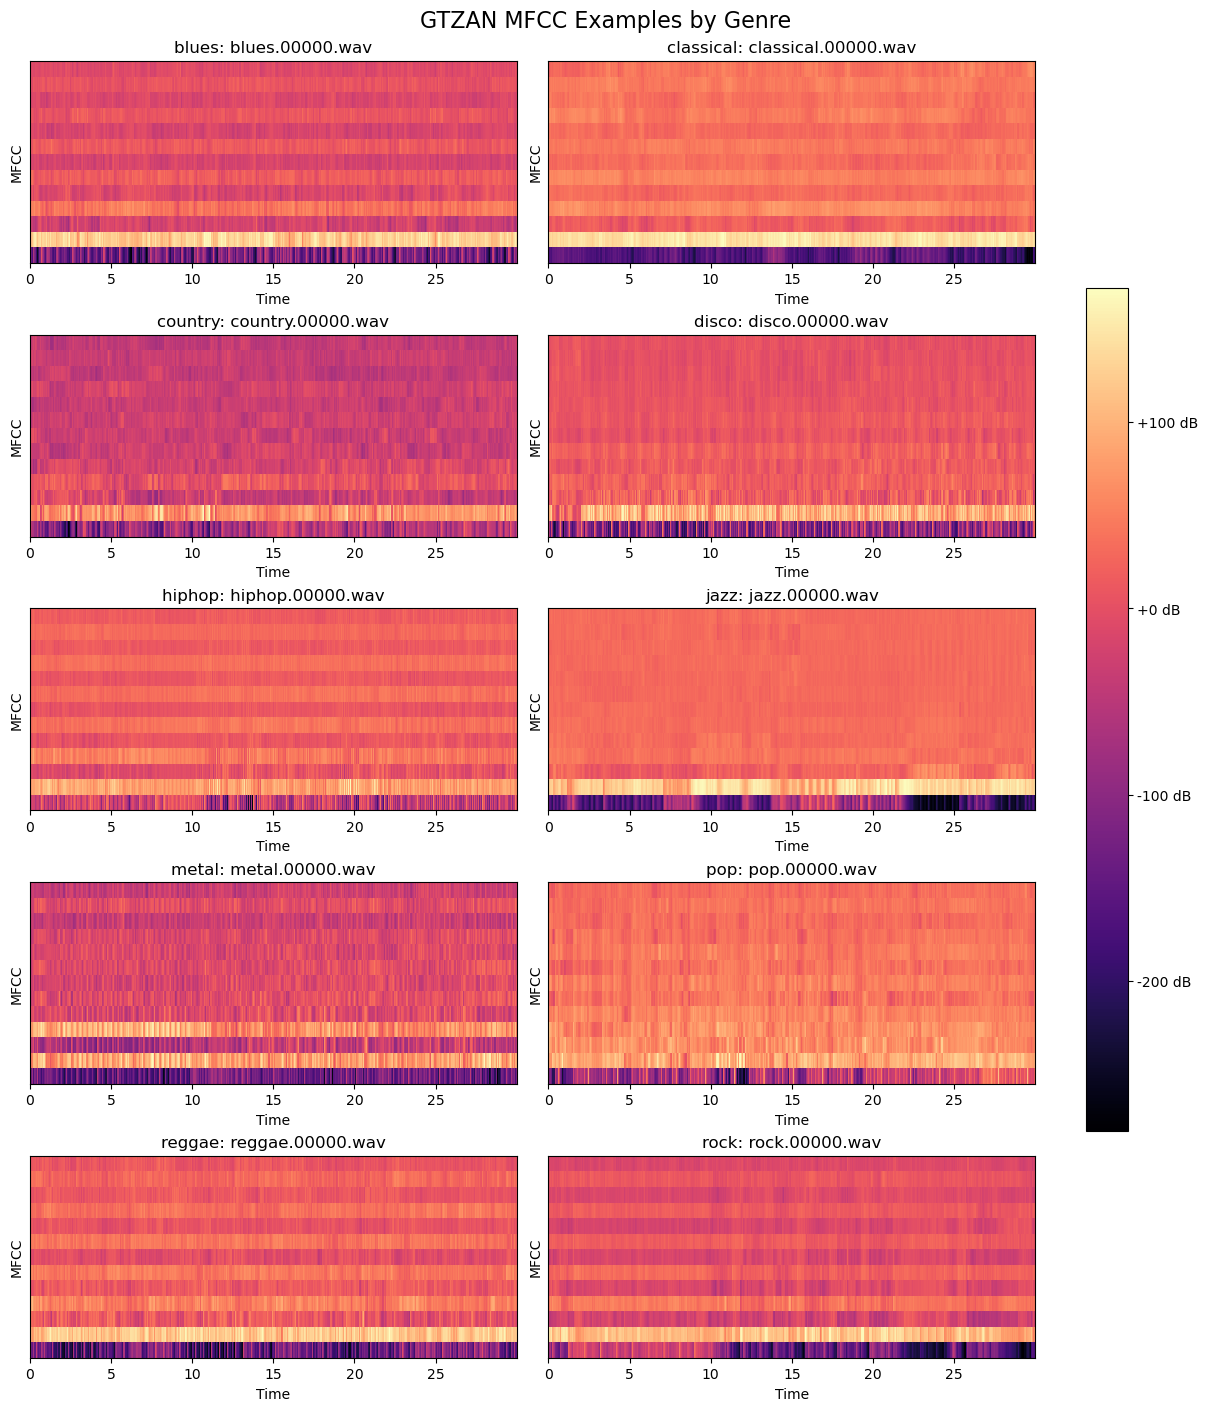

In [26]:
plot_mfcc_examples(dataset_path=dataset_path, output_path=None)